In [1]:
import pandas as pd
import requests

from getpass import getpass

In [2]:
API_KEY = getpass("OpenAQ API key: ")

OpenAQ API key:  ········


In [3]:
url = "https://api.openaq.org/v3/parameters/2/latest"

response = requests.get(
    url,
    headers={"X-API-Key": API_KEY},
    params={"limit": 1000}
)

response.raise_for_status()

data = response.json()

In [4]:
records = []

for item in data["results"]:
    coordinates = item.get("coordinates") or {}

    latitude = coordinates.get("latitude")
    longitude = coordinates.get("longitude")

    if latitude is None or longitude is None:
        continue

    records.append({
        "datetime": item["datetime"]["utc"],
        "pm25": item["value"],
        "latitude": latitude,
        "longitude": longitude,
        "sensor_id": item["sensorsId"],
        "location_id": item["locationsId"],
    })

df = pd.DataFrame(records)

df.head()

,datetime,pm25,latitude,longitude,sensor_id,location_id
0,2026-09-06T11:00:00Z,20.0,35.218150,128.574250,8539597,2622686
1,2026-09-05T23:00:00Z,-1.0,54.883614,23.835835,23735,8152
2,2021-08-09T11:00:00Z,16.0,40.146500,117.070900,238048,43487
3,2025-08-09T14:00:00Z,9.0,37.645530,-118.966760,7320157,1772963
4,2026-09-06T10:00:00Z,6.5,38.592460,-82.806770,6236505,1066093


In [6]:
df.shape

(1000, 6)

In [8]:
df.describe()

,pm25,latitude,longitude,sensor_id,location_id
count,1000.000000,1000.000000,1000.000000,1.000000e+03,1.000000e+03
mean,143.439949,33.090648,25.465564,7.488254e+06,2.272940e+06
std,1398.051611,19.606826,93.930040,5.075747e+06,1.924215e+06
min,-9999.000000,-45.887395,-156.683350,1.180000e+02,7.300000e+01
25%,3.000000,32.957305,-76.035443,1.326830e+06,4.331025e+04
50%,7.000000,37.404167,25.482217,8.534764e+06,2.623092e+06
75%,14.547500,42.393272,126.708310,1.007061e+07,2.954252e+06
max,9999.000000,62.454710,175.924593,1.716136e+07,6.477166e+06


In [9]:
df.head(11)

,datetime,pm25,latitude,longitude,sensor_id,location_id
0,2026-09-06T11:00:00Z,20.000000,35.218150,128.574250,8539597,2622686
1,2026-09-05T23:00:00Z,-1.000000,54.883614,23.835835,23735,8152
2,2021-08-09T11:00:00Z,16.000000,40.146500,117.070900,238048,43487
3,2025-08-09T14:00:00Z,9.000000,37.645530,-118.966760,7320157,1772963
4,2026-09-06T10:00:00Z,6.500000,38.592460,-82.806770,6236505,1066093
5,2024-12-09T12:00:00Z,6.000000,53.129419,23.108025,7754909,2146563
6,2022-10-31T01:45:00Z,154.810000,29.966942,76.875879,20961,7282
7,2024-07-21T20:00:00Z,15.872727,45.081634,13.643802,9957979,2953756
8,2026-07-29T19:00:00Z,8.190000,-38.326760,146.326100,9969693,10819
9,2026-07-03T07:00:00Z,0.000000,38.050430,-122.154540,9963443,2954721


In [10]:
df.to_csv(
    "../data/raw/openaq_pm25_latest.csv",
    index=False
)

<Axes: xlabel='longitude', ylabel='latitude'>

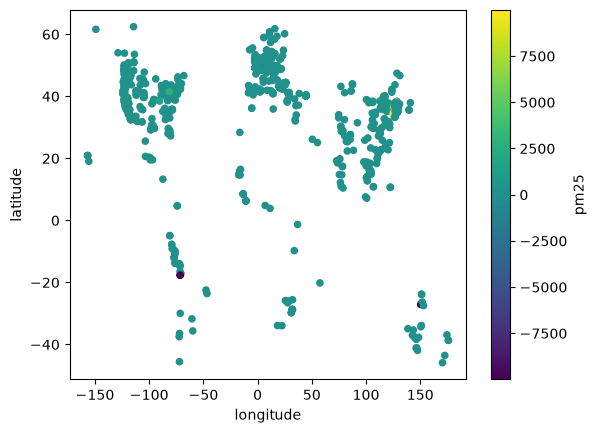

In [11]:
df.plot.scatter(
    x="longitude",
    y="latitude",
    c="pm25"
)